# manifold stuff

In [ ]:
import os
import sys
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import copy


# for loading data
import pandas as pd

# for manifold class
from abc import ABC, abstractmethod

# evaluation metrics
from functools import partial
import operator

In [ ]:
class Manifold(ABC):
  def __init__(self, ambient_dim: int):
    self.ambient_dim = ambient_dim

  @abstractmethod
  def project(self, x):
    """
    Project an ambient point onto the manifold.

    Parameters
    ----------
    x : Tensor
        Point in the ambient space.

    Returns
    -------
    Tensor
        Closest point on the manifold.
    """
    pass

  @abstractmethod
  def project_tangent(self, x, v):
    """
    Project an ambient vector onto the tangent space at x.

    Parameters
    ----------
    x : Tensor
    Point on the manifold.

    v : Tensor
    Ambient vector.

    Returns
    -------
    Tensor
    Tangent vector in T_xM.
    """
    pass

  @abstractmethod
  def exp(self,x,v):
    """
    x: point on manifold
    v: tangent vector

    exponential map returns the point on manifold reached by following
    the unique geodesic starting at x whose initial velocity is v for a distance equal to
    the norm ∥v∥
    """
    pass

  @abstractmethod
  def log(self,x,y):
    """
    x: point on manifold
    y: point on manifold

    logarithmic map returns the initial velocity of the geodesic starting at x and reaching y
    """
    pass

  @abstractmethod
  def dist(self,x,y):
    """
    Geodesic distance between x and y.
    Returns
    -------
    float or Tensor
    Distance along the manifold.
    """
    pass


In [ ]:
class FlatTorus(Manifold):
    """
    Flat n-dimensional torus:
    T^n = S^1 * ... * S^1

    Each circle is represented extrinsically in R^2, so:
    manifold dimension = n_circles
    ambient dimension = 2 * n_circles

    For the protein/checkerboard experiment:
    n_circles = 2
    T^2 is represented in R^4.
    """
    def __init__(self, n_circles=2, atol=1e-6):
        if n_circles < 1:
            raise ValueError(
                "Flat torus requires at least one circle."
            )

        self.n_circles = n_circles

        # Each circle S^1 is embedded in R^2.
        ambient_dim = 2 * n_circles
        super().__init__(ambient_dim)

        self.manifold_dim = n_circles
        self.atol = atol

    # helper functions

    def _check_last_dim(self, x):
        if x.shape[-1] != self.ambient_dim:
            raise ValueError(
                f"Expected last dimension to be "
                f"{self.ambient_dim}, but got {x.shape[-1]}."
            )

    def _reshape_blocks(self, x):
        """
        Convert (..., 2 * n_circles)

        into (..., n_circles, 2).

        For T^2: (..., 4) -> (..., 2, 2)
        """
        self._check_last_dim(x)

        return x.reshape(
            *x.shape[:-1], # unpacks for batch size etc, only changes last dim
            self.n_circles, # always 2
            2,
        )
        # suppose batch 6 of 4
        # changes to 6 of 2x2

    def _block_norm(self, x):
        """
        Return the norm of each R^2 circle block.

        Input: (..., 2 * n_circles)

        Output: (..., n_circles)
        """
        x_blocks = self._reshape_blocks(x)

        return torch.linalg.norm(
            x_blocks,
            dim=-1,
        )

    def _block_inner(self, x, y):
        """
        Compute inner products separately for each circle block.

        Broadcasting is allowed.
        """
        x, y = torch.broadcast_tensors(x, y) # broadcast shapes of x&y

        x_blocks = self._reshape_blocks(x)
        y_blocks = self._reshape_blocks(y)

        return torch.sum(
            x_blocks * y_blocks,
            dim=-1,
        )
        # computes x11*y11, x12*y12 etc
        # then sum x11*y11 + x12*y12

    # Validation functions

    def _check_point(self, x):
        """
        Check that every R^2 block has unit norm.
        """
        self._check_last_dim(x)

        norms = self._block_norm(x)

        if torch.isnan(norms).any():
            raise ValueError(
                "Point block norms contain NaN values."
            )

        if not torch.allclose(
            norms, torch.ones_like(norms),
            atol=self.atol, rtol=0.0,
        ):
            max_err = torch.max(
                torch.abs(norms - 1.0)
            ).item()

            raise ValueError(
                "Points are not on the flat torus. "
                f"Maximum block-norm error = {max_err:.3e}"
            )

        return True

    def _check_tangent(self, x, v):
        """
        For every circle block j, verify
         <x_j, v_j> = 0.

        x and v may be broadcastable rather than having
        exactly the same shape.
        """
        self._check_last_dim(x)
        self._check_last_dim(v)
        self._check_point(x)

        x, v = torch.broadcast_tensors(x, v)

        inner = self._block_inner(x, v)

        if torch.isnan(inner).any():
            raise ValueError(
                "Tangent-space inner products contain NaNs."
            )

        if not torch.allclose(
            inner, torch.zeros_like(inner),
            atol=self.atol, rtol=0.0,
        ):
            max_err = torch.max(
                torch.abs(inner)
            ).item()

            raise ValueError(
                "v is not tangent to every circle factor at x. "
                f"Maximum block inner product = {max_err:.3e}"
            )

        return True

    # geometric operations

    def project(self, x):
        """
        Project each R^2 block onto its unit circle.

        For T^2: (a, b, c, d)

        becomes
        ((a, b) / ||(a, b)||,
        (c, d) / ||(c, d)||).
        """
        self._check_last_dim(x)

        x_blocks = self._reshape_blocks(x)

        norms = torch.linalg.norm(
            x_blocks,
            dim=-1,
            keepdim=True,
        )

        eps = 1e-12
        safe_norms = norms.clamp_min(eps)

        projected = x_blocks / safe_norms

        # if a network outputs an exactly zero block, its
        # direction is undefined. Use (1, 0) as a safe fallback.
        fallback = torch.zeros_like(x_blocks)
        fallback[..., 0] = 1.0 # ... means all preceding dimensions

        projected = torch.where(
            norms > eps, projected, fallback,
        )

        return projected.reshape(
            *x.shape[:-1], self.ambient_dim,
        )
        # conversts back shape from 2,2 to 4

    def project_tangent(self, x, v):
        """
        Project each R^2 block of v onto the tangent line
        of its corresponding circle at x.
        """
        self._check_last_dim(x)
        self._check_last_dim(v)
        self._check_point(x)

        # permits pairwise broadcasted calculations such as:
        # x: (G, 1, 4)
        # v: (G, P, 4)
        x, v = torch.broadcast_tensors(x, v)

        x_blocks = self._reshape_blocks(x)
        v_blocks = self._reshape_blocks(v)

        inner = torch.sum(
            x_blocks * v_blocks,
            dim=-1, keepdim=True,
        )

        projected = (
            v_blocks - inner * x_blocks
        )

        return projected.reshape(
            *projected.shape[:-2],
            self.ambient_dim,
        )

    def exp(self, x, v):
        """
        Product exponential map.

        Apply the circle exponential map independently
        to every circle factor.
        """
        self._check_point(x)
        self._check_tangent(x, v)

        x, v = torch.broadcast_tensors(x, v)

        x_blocks = self._reshape_blocks(x)
        v_blocks = self._reshape_blocks(v)

        # one norm for each tangent vector block
        v_norm = torch.linalg.norm(
            v_blocks,
            dim=-1, keepdim=True,
        )

        eps = 1e-12

        safe_v_norm = torch.where(
            v_norm > eps,
            v_norm, torch.ones_like(v_norm),
        )

        sinc = (
            torch.sin(safe_v_norm)
            / safe_v_norm
        )

        # taylor approximation near zero:
        # sin(r) / r = 1 - r^2 / 6 + O(r^4)
        sinc = torch.where(
            v_norm > eps,
            sinc, 1.0 - (v_norm ** 2) / 6.0,
        )

        out_blocks = (
            torch.cos(v_norm) * x_blocks + sinc * v_blocks
        )

        out = out_blocks.reshape(
            *out_blocks.shape[:-2], self.ambient_dim,
        )

        # projection removes small floating-point errors.
        return self.project(out)

    def log(self, x, y):
        """
        Product logarithmic map.

        For each circle, compute the shortest signed angular
        difference from x to y and multiply it by the oriented
        unit tangent at x.
        """
        self._check_point(x)
        self._check_point(y)

        # pairwise computations:
        # x: (G, 1, 4)
        # y: (1, P, 4)
        # output: (G, P, 4)
        x, y = torch.broadcast_tensors(x, y)

        x_blocks = self._reshape_blocks(x)
        y_blocks = self._reshape_blocks(y)

        # cos(delta) for every circle factor
        dot = torch.sum(
            x_blocks * y_blocks,
            dim=-1,
        )

        # sin(delta) for every circle factor
        determinant = (
            x_blocks[..., 0] * y_blocks[..., 1]
            - x_blocks[..., 1] * y_blocks[..., 0]
        )

        # Principal signed angle in [-pi, pi].
        delta = torch.atan2(
            determinant,
            dot,
        )

        # If x = (x_1, x_2), then the positively oriented
        # unit tangent is Jx = (-x_2, x_1).
        tangent_basis = torch.stack(
            (
                -x_blocks[..., 1],
                x_blocks[..., 0],
            ),
            dim=-1,
        )

        log_blocks = (
            delta.unsqueeze(-1)
            * tangent_basis
        )

        out = log_blocks.reshape(
            *log_blocks.shape[:-2],
            self.ambient_dim,
        )

        # Numerical safety.
        return self.project_tangent(x, out)

    def dist(self, x, y):
        """
        Product geodesic distance:

            sqrt(delta_1^2 + ... + delta_n^2),

        where each delta_j is the shortest wrapped angular
        difference on one circle.
        """
        self._check_point(x)
        self._check_point(y)

        x, y = torch.broadcast_tensors(x, y)

        x_blocks = self._reshape_blocks(x)
        y_blocks = self._reshape_blocks(y)

        dot = torch.sum(
            x_blocks * y_blocks,
            dim=-1,
        )

        determinant = (
            x_blocks[..., 0] * y_blocks[..., 1]
            - x_blocks[..., 1] * y_blocks[..., 0]
        )

        delta = torch.atan2(
            determinant,
            dot,
        )

        return torch.linalg.norm(
            delta,
            dim=-1,
        )

    # ============================================================
    # Coordinate conversion helpers
    # ============================================================

    def from_angles(self, angles):
        """
        Convert angular coordinates to the ambient embedding.

        Input:
            (..., n_circles)

        Output:
            (..., 2 * n_circles)

        For T^2:

            (theta_1, theta_2)

        becomes

            (cos(theta_1), sin(theta_1),
             cos(theta_2), sin(theta_2)).
        """
        if angles.shape[-1] != self.n_circles:
            raise ValueError(
                f"Expected {self.n_circles} angles, "
                f"but got {angles.shape[-1]}."
            )

        blocks = torch.stack(
            (
                torch.cos(angles),
                torch.sin(angles),
            ),
            dim=-1,
        )

        return blocks.reshape(
            *angles.shape[:-1],
            self.ambient_dim,
        )

    def to_angles(self, x):
        """
        Convert the ambient representation back to angles
        in approximately [-pi, pi].
        """
        self._check_point(x)

        x_blocks = self._reshape_blocks(x)

        return torch.atan2(
            x_blocks[..., 1],
            x_blocks[..., 0],
        )

    def wrap_angles(self, angles):
        """
        Wrap arbitrary angles into the principal interval
        approximately [-pi, pi].
        """
        return torch.atan2(
            torch.sin(angles),
            torch.cos(angles),
        )

    def sample(self, n, device=None, dtype=None):
        """
        Sample uniformly from the flat torus.

        This is a generic manifold sampler, not the future
        checkerboard target sampler.
        """
        angles = (
            2.0
            * torch.pi
            * torch.rand(
                n,
                self.n_circles,
                device=device,
                dtype=dtype,
            )
            - torch.pi
        )

        return self.from_angles(angles)

torus = FlatTorus(n_circles=2)

# data prep

In [ ]:
%cd /content

!git clone --depth 1 \
    https://github.com/harryjo97/riemannian-diffusion-mixture-torch.git

!pip install -q biopython

/content
fatal: destination path 'riemannian-diffusion-mixture-torch' already exists and is not an empty directory.


In [ ]:
%cd /content/riemannian-diffusion-mixture-torch/data/top500

!bash batch_download.sh -f list_file.txt -p

/content/riemannian-diffusion-mixture-torch/data/top500


In [ ]:
from pathlib import Path

top500_dir = Path(
    "/content/riemannian-diffusion-mixture-torch/data/top500"
)

pdb_gz_files = list(top500_dir.glob("*.pdb.gz"))

print("Downloaded structures:", len(pdb_gz_files))
print("First few:", [path.name for path in pdb_gz_files[:5]])

Downloaded structures: 494
First few: ['1HKA.pdb.gz', '1ABA.pdb.gz', '1BEH.pdb.gz', '1WHI.pdb.gz', '1VNS.pdb.gz']


In [ ]:
%cd /content/riemannian-diffusion-mixture-torch/data/top500

!python get_torsion_angle.py

/content/riemannian-diffusion-mixture-torch/data/top500
About to load Bio.PDB and the PDB file...
Done
About to save angles to file...
Chain A
About to load Bio.PDB and the PDB file...
Done
About to save angles to file...
Chain A
About to load Bio.PDB and the PDB file...
Done
About to save angles to file...
Chain A
About to load Bio.PDB and the PDB file...
/usr/local/lib/python3.12/dist-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 9729.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 10527.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 11317.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 12267.
  warni

In [ ]:
angles_path = top500_dir / "aggregated_angles.tsv"

print("Exists:", angles_path.exists())
print("Size in MB:", angles_path.stat().st_size / 1e6)

Exists: True
Size in MB: 8.083796


In [ ]:
import pandas as pd

protein_df = pd.read_csv(
    angles_path,
    sep="\t",
    header=None,
    names=[
        "source",
        "phi",
        "psi",
        "amino_type",
    ],
)

print(protein_df.head())
print()
print(protein_df.shape)
print()
print(protein_df["amino_type"].value_counts())

             source         phi         psi amino_type
0  119L:ChainA:ASN2 -147.962169  178.182401    General
1  119L:ChainA:ILE3  -55.072605  -44.611038    General
2  119L:ChainA:PHE4  -59.092978  -50.062197    General
3  119L:ChainA:GLU5  -66.160999  -36.985323    General
4  119L:ChainA:MET6  -63.034586  -51.621208    General

(166035, 4)

amino_type
General    138208
Glycine     13283
Proline      7634
Pre-Pro      6910
Name: count, dtype: int64


In [ ]:
protein_df["pdb_id"] = (
    protein_df["source"]
    .str.split(":")
    .str[0]
    .str.upper()
)

print(protein_df[[
    "source",
    "pdb_id",
    "phi",
    "psi",
    "amino_type",
]].head())

             source pdb_id         phi         psi amino_type
0  119L:ChainA:ASN2   119L -147.962169  178.182401    General
1  119L:ChainA:ILE3   119L  -55.072605  -44.611038    General
2  119L:ChainA:PHE4   119L  -59.092978  -50.062197    General
3  119L:ChainA:GLU5   119L  -66.160999  -36.985323    General
4  119L:ChainA:MET6   119L  -63.034586  -51.621208    General


In [ ]:
amino_type = "General"

general_df = (
    protein_df[
        protein_df["amino_type"] == amino_type
    ]
    .copy()
    .reset_index(drop=True)
)

print(general_df.shape)
print(general_df.head())

(138208, 5)
             source         phi         psi amino_type pdb_id
0  119L:ChainA:ASN2 -147.962169  178.182401    General   119L
1  119L:ChainA:ILE3  -55.072605  -44.611038    General   119L
2  119L:ChainA:PHE4  -59.092978  -50.062197    General   119L
3  119L:ChainA:GLU5  -66.160999  -36.985323    General   119L
4  119L:ChainA:MET6  -63.034586  -51.621208    General   119L


In [ ]:
degrees = torch.tensor(
    general_df[["phi", "psi"]]
    .to_numpy(dtype=np.float32),
    dtype=torch.float32,
)

# Match the repository's wrapping convention:
# degrees modulo 360, followed by conversion to radians.
protein_angles = (
    torch.remainder(degrees, 360.0)
    * torch.pi
    / 180.0
)

protein_torus_coords = torus.from_angles(
    protein_angles
)

print("Angles shape:", protein_angles.shape)
print("Torus coordinates shape:", protein_torus_coords.shape)

torus._check_point(protein_torus_coords)

Angles shape: torch.Size([138208, 2])
Torus coordinates shape: torch.Size([138208, 4])


True

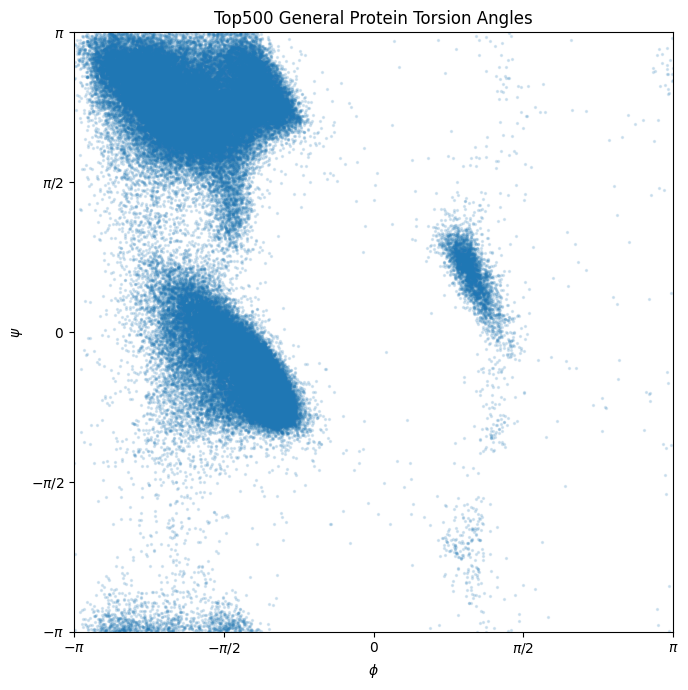

In [ ]:
angles_for_plot = (
    torus.to_angles(protein_torus_coords)
    .cpu()
    .numpy()
)

plt.figure(figsize=(7, 7))

plt.scatter(
    angles_for_plot[:, 0],
    angles_for_plot[:, 1],
    s=2,
    alpha=0.15,
)

plt.xlim(-np.pi, np.pi)
plt.ylim(-np.pi, np.pi)
plt.gca().set_aspect("equal")

ticks = [
    -np.pi,
    -np.pi / 2,
    0,
    np.pi / 2,
    np.pi,
]

labels = [
    r"$-\pi$",
    r"$-\pi/2$",
    r"$0$",
    r"$\pi/2$",
    r"$\pi$",
]

plt.xticks(ticks, labels)
plt.yticks(ticks, labels)

plt.xlabel(r"$\phi$")
plt.ylabel(r"$\psi$")
plt.title("Top500 General Protein Torsion Angles")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

seed = 42
rng = np.random.default_rng(seed)

pdb_ids = protein_df["pdb_id"].drop_duplicates().to_numpy()
rng.shuffle(pdb_ids)

n_pdb = len(pdb_ids)
n_train = int(0.8 * n_pdb)
n_val = int(0.1 * n_pdb)

train_ids = set(pdb_ids[:n_train])
val_ids = set(pdb_ids[n_train:n_train + n_val])
test_ids = set(pdb_ids[n_train + n_val:])

def identify_split(pdb_id):
    if pdb_id in train_ids:
        return "train"
    if pdb_id in val_ids:
        return "validation"
    return "test"

protein_df["split"] = protein_df["pdb_id"].map(identify_split)

print(
    protein_df.groupby(
        ["split", "amino_type"]
    ).size().unstack(fill_value=0)
)

assert not train_ids & val_ids
assert not train_ids & test_ids
assert not val_ids & test_ids

amino_type  General  Glycine  Pre-Pro  Proline
split                                         
test          11579     1089      577      649
train        108470    10542     5280     5806
validation    18159     1652     1053     1179


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path

protein_drive_dir = Path(
    "/content/drive/MyDrive/protein_dataset"
)
protein_drive_dir.mkdir(parents=True, exist_ok=True)

master_path = protein_drive_dir / "top500_angles_master.tsv"

protein_df.to_csv(
    master_path,
    sep="\t",
    index=False,
)

print("Saved master dataset to:", master_path)
print("Rows saved:", len(protein_df))
print(protein_df["amino_type"].value_counts())

Saved master dataset to: /content/drive/MyDrive/protein_dataset/top500_angles_master.tsv
Rows saved: 166035
amino_type
General    138208
Glycine     13283
Proline      7634
Pre-Pro      6910
Name: count, dtype: int64


In [ ]:
requested_ids = {
    item.strip().upper()
    for item in (
        top500_dir / "list_file.txt"
    ).read_text().split(",")
    if item.strip()
}

downloaded_ids = {
    path.name.removesuffix(".pdb.gz").upper()
    for path in top500_dir.glob("*.pdb.gz")
}

missing_ids = sorted(requested_ids - downloaded_ids)

print("Requested:", len(requested_ids))
print("Downloaded:", len(downloaded_ids))
print("Missing:", missing_ids)

Requested: 494
Downloaded: 494
Missing: []


In [ ]:
expected_types = {
    "General",
    "Glycine",
    "Proline",
    "Pre-Pro",
}

assert protein_df[["phi", "psi"]].notna().all().all()
assert protein_df["phi"].between(-180, 180).all()
assert protein_df["psi"].between(-180, 180).all()
assert set(protein_df["amino_type"].unique()) == expected_types
assert protein_df["pdb_id"].notna().all()

print("Duplicate source labels:",
      protein_df["source"].duplicated().sum())

Duplicate source labels: 7
